## 1. Load Dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes_prediction_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 2. Basic Data Check 

In [10]:
df.shape

(100000, 9)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [12]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [13]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(3854)

In [17]:
df = df.drop_duplicates()

## 3. Diabetes Rate

In [19]:
diabetes_rate = df['diabetes'].mean() * 100
print(f"Diabetes Rate: {diabetes_rate:.2f}%")

Diabetes Rate: 8.82%


In [20]:
df['diabetes'].value_counts()

diabetes
0    87664
1     8482
Name: count, dtype: int64

In [21]:
df['diabetes'].value_counts(normalize=True) * 100

diabetes
0    91.178
1     8.822
Name: proportion, dtype: float64

## 4. Age Group

In [22]:
def age_group(age):
    if age <= 30:
        return "18-30"
    elif age <= 45:
        return "31-45"
    elif age <= 60:
        return "46-60"
    else:
        return "60+"

df['Age_Group'] = df['age'].apply(age_group)

C:\Users\KaziKudratAli\AppData\Local\Temp\ipykernel_23124\43383560.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age_Group'] = df['age'].apply(age_group)


## 5. BMI Category

In [23]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Healthy"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df['BMI_Category'] = df['bmi'].apply(bmi_category)

C:\Users\KaziKudratAli\AppData\Local\Temp\ipykernel_23124\545902584.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['BMI_Category'] = df['bmi'].apply(bmi_category)


## 6. Blood Glucose Category

In [24]:
def glucose_category(glucose):
    if glucose < 100:
        return "Normal"
    elif glucose < 126:
        return "Prediabetes"
    elif glucose < 200:
        return "High"
    else:
        return "Critical"

df['Glucose_Category'] = df['blood_glucose_level'].apply(glucose_category)

C:\Users\KaziKudratAli\AppData\Local\Temp\ipykernel_23124\1949597424.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Glucose_Category'] = df['blood_glucose_level'].apply(glucose_category)


## 7. HbA1c Category

In [25]:
def hba1c_category(value):
    if value < 5.7:
        return "Normal"
    elif value < 6.5:
        return "Prediabetic"
    else:
        return "Diabetic"

df['HbA1c_Category'] = df['HbA1c_level'].apply(hba1c_category)

C:\Users\KaziKudratAli\AppData\Local\Temp\ipykernel_23124\2855817413.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['HbA1c_Category'] = df['HbA1c_level'].apply(hba1c_category)


## 8. Diabetes by Gender 

In [26]:
gender_diabetes = df.groupby('gender')['diabetes'].mean() * 100
gender_diabetes.sort_values(ascending=False)

gender
Male      10.095829
Female     7.918306
Other      0.000000
Name: diabetes, dtype: float64

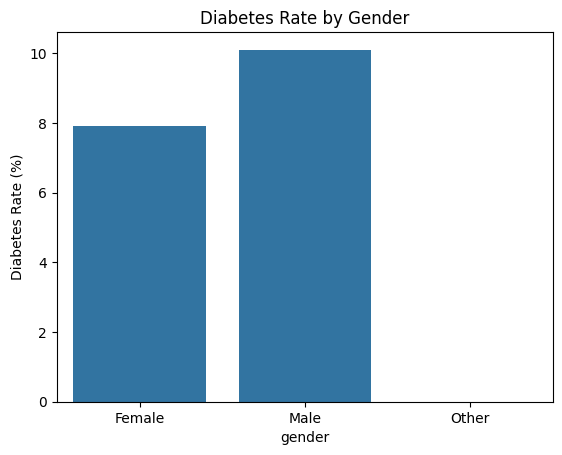

In [27]:
sns.barplot(x=gender_diabetes.index, y=gender_diabetes.values)
plt.title("Diabetes Rate by Gender")
plt.ylabel("Diabetes Rate (%)")
plt.show()

## 9. Diabetes by Age Group 

In [29]:
age_diabetes = df.groupby('Age_Group')['diabetes'].mean() * 100
age_order = ["18-30", "31-45", "46-60", "60+"]

age_diabetes = age_diabetes.reindex(age_order)
age_diabetes

Age_Group
18-30     0.928497
31-45     4.703941
46-60    11.792040
60+      20.818403
Name: diabetes, dtype: float64

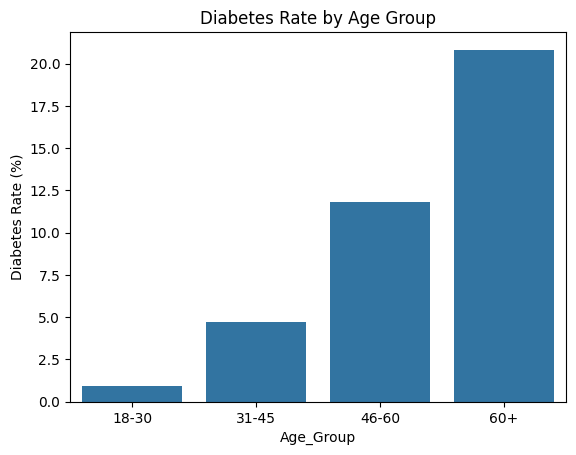

In [30]:
sns.barplot(x=age_diabetes.index, y=age_diabetes.values)
plt.title("Diabetes Rate by Age Group")
plt.ylabel("Diabetes Rate (%)")
plt.show()

## 10. Diabetes by BMI Category

In [31]:
bmi_diabetes = df.groupby('BMI_Category')['diabetes'].mean() * 100
bmi_order = ["Underweight", "Healthy", "Overweight", "Obese"]

bmi_diabetes = bmi_diabetes.reindex(bmi_order)
bmi_diabetes

BMI_Category
Underweight     0.753739
Healthy         3.885987
Overweight      7.927571
Obese          17.985550
Name: diabetes, dtype: float64

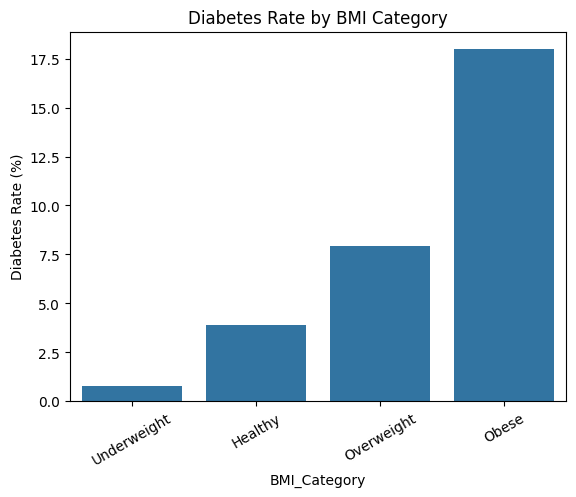

In [32]:
sns.barplot(x=bmi_diabetes.index, y=bmi_diabetes.values)
plt.title("Diabetes Rate by BMI Category")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=30)
plt.show()

## 11. Diabetes by Hypertension

In [33]:
hypertension_diabetes = df.groupby('hypertension')['diabetes'].mean() * 100
hypertension_diabetes

hypertension
0     7.212043
1    27.958719
Name: diabetes, dtype: float64

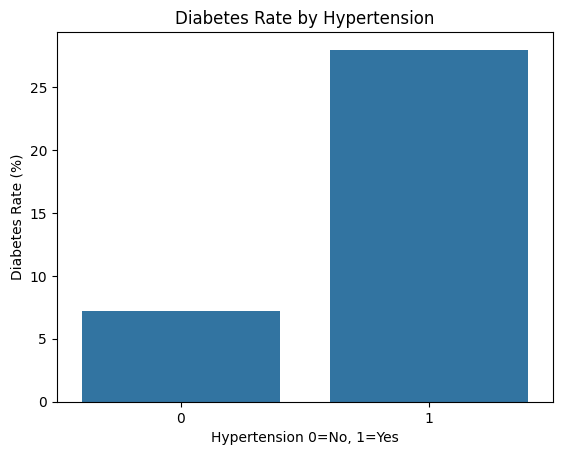

In [34]:
sns.barplot(x=hypertension_diabetes.index, y=hypertension_diabetes.values)
plt.title("Diabetes Rate by Hypertension")
plt.xlabel("Hypertension 0=No, 1=Yes")
plt.ylabel("Diabetes Rate (%)")
plt.show()

## 12. Diabetes by Heart Disease

In [35]:
heart_diabetes = df.groupby('heart_disease')['diabetes'].mean() * 100
heart_diabetes

heart_disease
0     7.823428
1    32.296712
Name: diabetes, dtype: float64

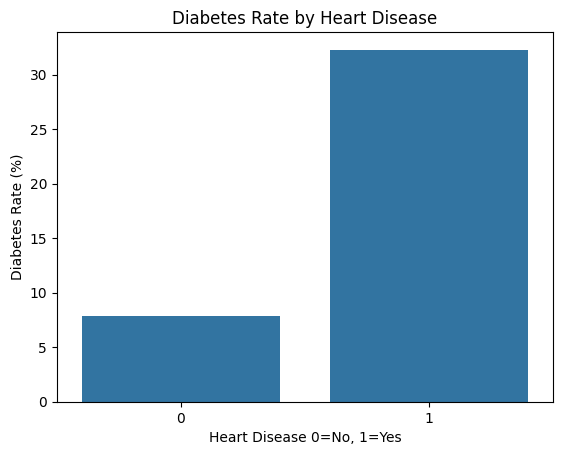

In [36]:
sns.barplot(x=heart_diabetes.index, y=heart_diabetes.values)
plt.title("Diabetes Rate by Heart Disease")
plt.xlabel("Heart Disease 0=No, 1=Yes")
plt.ylabel("Diabetes Rate (%)")
plt.show()

## Diabetes by Smoking History 

In [37]:
smoking_diabetes = df.groupby('smoking_history')['diabetes'].mean() * 100
smoking_diabetes.sort_values(ascending=False) 

smoking_history
former         17.098613
ever           11.805903
not current    10.837129
current        10.307709
never           9.701145
No Info         4.393833
Name: diabetes, dtype: float64

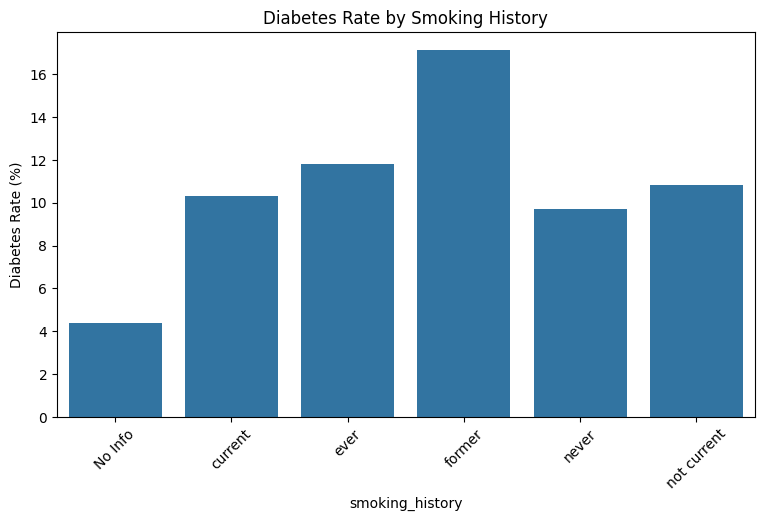

In [38]:
plt.figure(figsize=(9,5))
sns.barplot(x=smoking_diabetes.index, y=smoking_diabetes.values)
plt.title("Diabetes Rate by Smoking History")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=45)
plt.show()

## 14. Blood Glucose vs Diabetes

In [39]:
df.groupby('diabetes')['blood_glucose_level'].mean() 

diabetes
0    132.818489
1    194.026173
Name: blood_glucose_level, dtype: float64

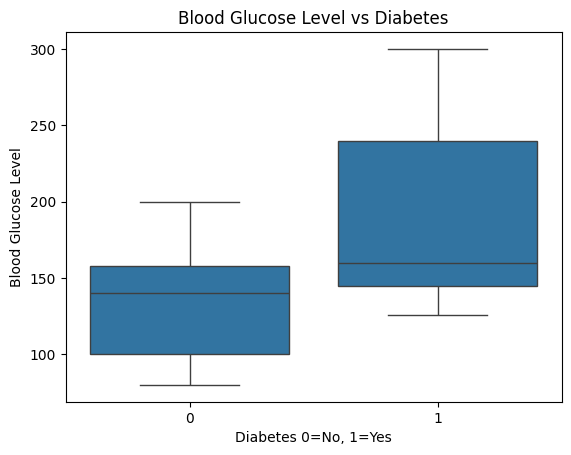

In [40]:
sns.boxplot(x='diabetes', y='blood_glucose_level', data=df)
plt.title("Blood Glucose Level vs Diabetes")
plt.xlabel("Diabetes 0=No, 1=Yes")
plt.ylabel("Blood Glucose Level")
plt.show()

## 15. HbA1c vs Diabetes

In [41]:
df.groupby('diabetes')['HbA1c_level'].mean() 

diabetes
0    5.396936
1    6.934827
Name: HbA1c_level, dtype: float64

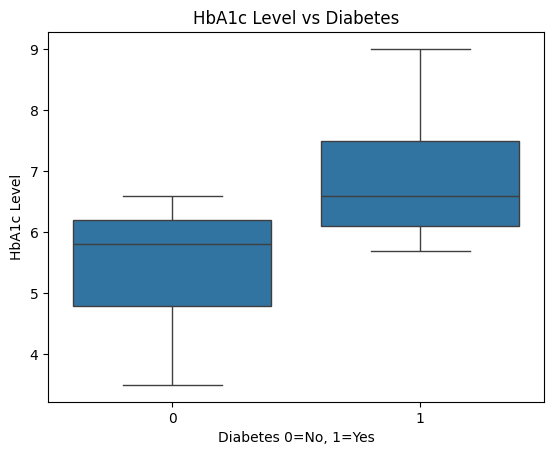

In [42]:
sns.boxplot(x='diabetes', y='HbA1c_level', data=df)
plt.title("HbA1c Level vs Diabetes")
plt.xlabel("Diabetes 0=No, 1=Yes")
plt.ylabel("HbA1c Level")
plt.show()

## 16. Correlation Heatmap

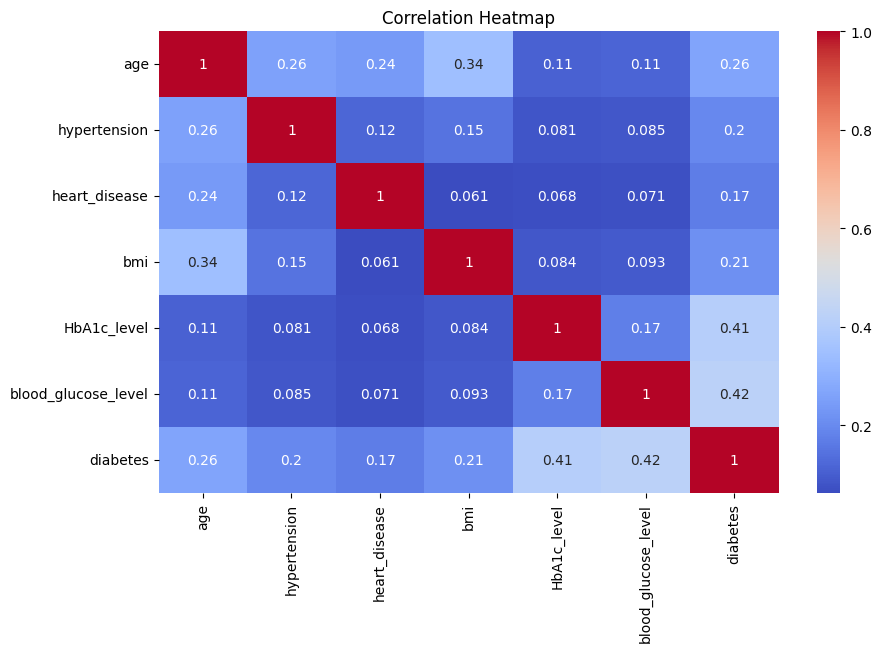

In [43]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 17. High Risk Patient Flag 

In [44]:
df['High_Risk_Patient'] = np.where(
    (df['age'] > 45) &
    (df['bmi'] >= 30) &
    (df['HbA1c_level'] >= 6.5) &
    (df['blood_glucose_level'] >= 126),
    "High Risk",
    "Normal Risk"
)

C:\Users\KaziKudratAli\AppData\Local\Temp\ipykernel_23124\719079834.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['High_Risk_Patient'] = np.where(


In [45]:
df['High_Risk_Patient'].value_counts()

High_Risk_Patient
Normal Risk    92792
High Risk       3354
Name: count, dtype: int64

## 18. Risk Score

In [46]:
df['Risk_Score'] = (
    (df['age'] > 45).astype(int) * 20 +
    (df['bmi'] >= 30).astype(int) * 20 +
    (df['hypertension'] == 1).astype(int) * 15 +
    (df['heart_disease'] == 1).astype(int) * 15 +
    (df['HbA1c_level'] >= 6.5).astype(int) * 15 +
    (df['blood_glucose_level'] >= 126).astype(int) * 15
) 

C:\Users\KaziKudratAli\AppData\Local\Temp\ipykernel_23124\1350694777.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Risk_Score'] = (


In [47]:
df[['age','bmi','hypertension','heart_disease','HbA1c_level','blood_glucose_level','Risk_Score','diabetes']].head()  

,age,bmi,hypertension,heart_disease,HbA1c_level,blood_glucose_level,Risk_Score,diabetes
0,80.0,25.19,0,1,6.6,140,65,0
1,54.0,27.32,0,0,6.6,80,35,0
2,28.0,27.32,0,0,5.7,158,15,0
3,36.0,23.45,0,0,5.0,155,15,0
4,76.0,20.14,1,1,4.8,155,65,0


## 19. Diabetes Rate by Risk Score Group 

In [48]:
def risk_group(score):
    if score <= 25:
        return "Low Risk"
    elif score <= 50:
        return "Medium Risk"
    else:
        return "High Risk"

df['Risk_Group'] = df['Risk_Score'].apply(risk_group)

C:\Users\KaziKudratAli\AppData\Local\Temp\ipykernel_23124\4238404955.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Risk_Group'] = df['Risk_Score'].apply(risk_group)


In [49]:
risk_diabetes = df.groupby('Risk_Group')['diabetes'].mean() * 100
risk_diabetes

Risk_Group
High Risk      34.081648
Low Risk        0.434225
Medium Risk     9.656562
Name: diabetes, dtype: float64

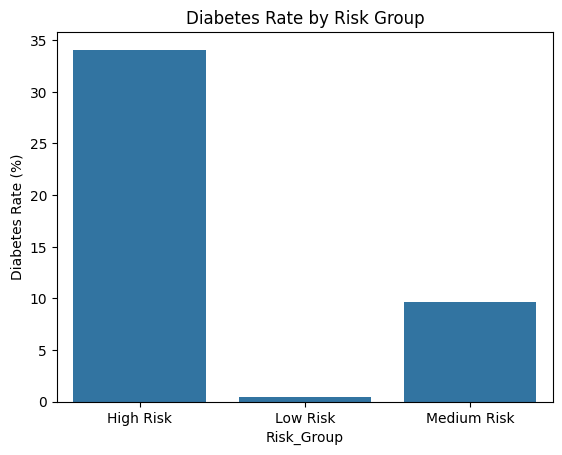

In [50]:
sns.barplot(x=risk_diabetes.index, y=risk_diabetes.values)
plt.title("Diabetes Rate by Risk Group")
plt.ylabel("Diabetes Rate (%)")
plt.show()

## 20. Export Cleaned Dataset 

In [51]:
df.to_csv("Diabetes_Cleaned_Dataset.csv", index=False) 